## ***INTRODUCTION***


## What are Adversarial Examples?

Adversarial examples are inputs to machine learning models that are intentionally
designed to cause the model to make mistakes. Despite being nearly imperceptible
to humans, these carefully crafted perturbations can fool state-of-the-art neural
networks with high confidence.

### Key Motivations for Studying Adversarial Attacks:

1. **Security**: Understanding vulnerabilities in ML systems deployed in critical
   applications (autonomous vehicles, medical diagnosis, facial recognition)

2. **Robustness**: Building more reliable models that generalize well to
   unexpected inputs

3. **Understanding**: Gaining insights into how neural networks make decisions
   and what features they rely on

### Real-World Impact:

- **Autonomous Vehicles**: Adversarial stickers on stop signs causing misclassification
- **Face Recognition**: Adversarial glasses that fool authentication systems
- **Malware Detection**: Malicious code disguised to evade ML-based antivirus
- **Medical AI**: Manipulated medical images leading to wrong diagnoses

### Evasion Attack:

Evasion attacks are a type of adversarial attack where an attacker subtly modifies input data to trick a trained machine learning model into making a wrong classification

### What You'll Learn:

This tutorial provides a complete, hands-on introduction to evasion attacks
using the Fast Gradient Sign Method (FGSM), one of the most fundamental and
widely-studied attack techniques. You'll learn:

- The mathematical foundations of gradient-based attacks
- How to implement FGSM from scratch in PyTorch
- How to visualize and analyze adversarial perturbations
- Defense mechanisms and their limitations
- Practical considerations for adversarial robustness

## ***THREAT MODEL & TERMINOLOGY***
## Threat Models in Adversarial Machine Learning

Understanding the attacker's capabilities is crucial for analyzing security:

### Attack Knowledge (Box Colors):

1. **White-Box Attack**:
   - Attacker has complete knowledge of the model
   - Architecture, parameters, training data, defense mechanisms
   - Can compute gradients directly
   - Example: FGSM, PGD, C&W attacks

2. **Black-Box Attack**:
   - No access to model internals
   - Only input-output queries allowed
   - Must rely on transferability or query-based methods
   - Example: Transfer attacks, score-based attacks

3. **Gray-Box Attack**:
   - Partial knowledge (e.g., architecture but not weights)
   - Intermediate difficulty

### Attack Specificity:

1. **Untargeted Attack**:
   - Goal: Make model predict ANY wrong class
   - Easier to achieve
   - Example: "Make this '7' predict anything except 7"

2. **Targeted Attack**:
   - Goal: Make model predict a SPECIFIC wrong class
   - More challenging
   - Example: "Make this '7' predict '1'"

### Attack Constraints:

1. **L∞ (L-infinity) Norm**:
   - Maximum per-pixel change bounded by ε
   - Most common in image domain
   - ||δ||∞ ≤ ε means |δᵢⱼ| ≤ ε for all pixels

2. **L₂ (Euclidean) Norm**:
   - Total perturbation energy bounded
   - √(Σδᵢⱼ²) ≤ ε

3. **L₀ Norm**:
   - Number of changed pixels bounded
   - Sparse perturbations

### Key Terminology:

- **Clean Example**: Original, unperturbed input
- **Adversarial Example**: Input + perturbation that fools the model
- **Perturbation (δ)**: The crafted noise added to input
- **Epsilon (ε)**: Maximum allowed perturbation magnitude
- **Attack Success Rate**: Percentage of adversarial examples that fool the model
- **Robustness**: Model's ability to resist adversarial attacks

## ***MATHEMATICS & INTUITION BEHIND FGSM***
## Fast Gradient Sign Method (FGSM): Theory & Derivation

### The Core Idea:

FGSM exploits the linear nature of neural networks in high-dimensional spaces.
Even though individual neurons are nonlinear, the overall model behavior is
often approximately linear locally.

### Mathematical Formulation:

Given:
- Input image: x
- True label: y
- Model: f(x) with parameters θ
- Loss function: L(θ, x, y)

**Goal**: Find adversarial example x' that maximizes loss while staying close to x

### Optimization Problem:

```
maximize L(θ, x + δ, y)
subject to ||δ||∞ ≤ ε
```

This is computationally expensive to solve exactly. FGSM provides a fast
approximation using a single gradient step.

### FGSM Derivation:

1. **Linear Approximation**:
   Using first-order Taylor expansion around x:
   ```
   L(θ, x + δ, y) ≈ L(θ, x, y) + δᵀ ∇ₓL(θ, x, y)
   ```

2. **Maximizing the Dot Product**:
   To maximize loss, we want δ to align with the gradient direction.
   Given constraint ||δ||∞ ≤ ε, the optimal perturbation is:
   ```
   δ = ε · sign(∇ₓL(θ, x, y))
   ```

3. **FGSM Update**:
   ```
   x_adv = x + ε · sign(∇ₓL(θ, x, y))
   ```
   
   With clipping to valid range:
   ```
   x_adv = clip(x + ε · sign(∇ₓL(θ, x, y)), x_min, x_max)
   ```

### Why Does This Work?

1. **High Dimensionality**: In a 28×28 MNIST image (784 pixels), even a tiny
   per-pixel perturbation of ε=0.01 can change the total input by up to
   784×0.01 = 7.84 in L₁ norm.

2. **Linear Behavior**: Neural networks often behave linearly in neighborhoods
   of training examples, making gradient-based attacks effective.

3. **Gradient Sensitivity**: Models trained with gradient descent are inherently
   sensitive to gradient information.

### Intuitive Understanding:

Think of the loss landscape as a hill. FGSM asks: "Which direction makes the
loss increase fastest?" Then it takes a single step in that direction. The
sign() function ensures we take the maximum allowed step (±ε) in each dimension.

**Mathematical Properties:**

- **Computational Efficiency**: Only one forward-backward pass required
- **Bounded Perturbation**: Guarantees ||δ||∞ = ε (if no clipping)
- **Untargeted**: Increases loss without specifying target class
- **One-Shot**: Non-iterative (unlike PGD which takes multiple steps)

### Limitations:

1. First-order approximation may not be accurate for large ε
2. Single step may not find optimal perturbation
3. Doesn't exploit non-linearities effectively


Just to make this a little more clear, let us look at the famous FGSM Panda example.
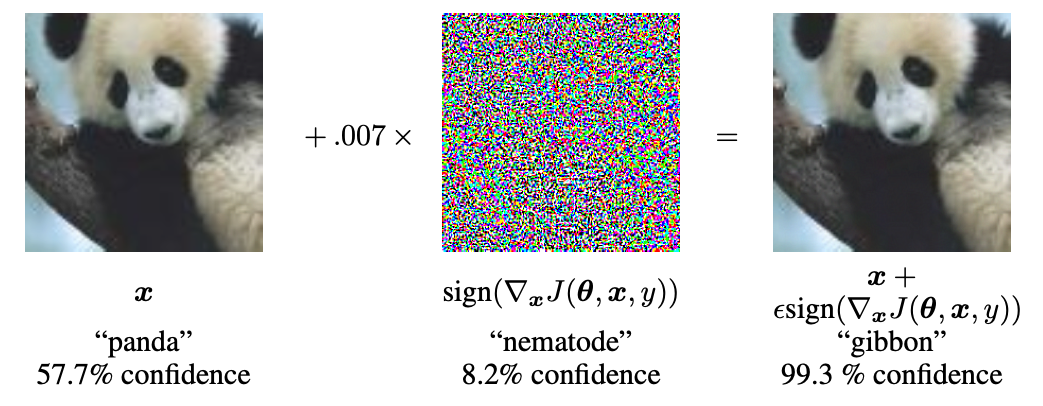


Let x be the original input image (a "panda") and y its ground-truth label. Let θ be the model parameters and J(θ, x, y) the training loss.

Compute the gradient of the loss with respect to the input: ∇_x J(θ, x, y)

Perturb the input with a small step in the sign of that gradient:
x' = x + ε * sign(∇_x J(θ, x, y))

(Example: ε = 0.007.) The perturbed image x' looks like a panda to humans but can be misclassified by the model (e.g., as a "gibbon").


**source: Explaining and Harnessing Adversarial Examples
Ian J. Goodfellow, Jonathon Shlens, Christian Szegedy**  

Now, lets move on to the implementation.

## ***ENVIRONMENT SETUP***


## Setting Up the Environment

Before we begin implementing attacks, we need to set up our Python environment
with the necessary libraries and configurations.

In [1]:
#pip install -q torch torchvision ipywidgets tqdm

### Import Libraries

We'll use:
- **PyTorch**: Deep learning framework for model building and automatic differentiation
- **torchvision**: Computer vision datasets and transformations
- **NumPy**: Numerical computing
- **Matplotlib**: Visualization
- **tqdm**: Progress bars
- **ipywidgets**: Interactive controls

In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

### Reproducibility Setup

For reproducible experiments, we seed all random number generators. This ensures
that running the notebook multiple times produces identical results.

In [3]:
def seed_all(seed=42):
    """Set seeds for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
print("✓ Random seeds set for reproducibility")

✓ Random seeds set for reproducibility


### Device Configuration

We automatically detect the best available hardware (GPU/TPU/CPU) for training
and inference. Modern Colab notebooks may have access to various accelerators.

In [4]:
# Device selection: try torch.accelerator when available, otherwise fallback to CUDA/CPU
try:
    if hasattr(torch, 'accelerator') and torch.accelerator.is_available():
        acc = torch.accelerator.current_accelerator().type
        device = torch.device(acc)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
except Exception as e:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Device: mps


## ***DATASET PREPARATION***

## MNIST Dataset

We use MNIST (Modified National Institute of Standards and Technology) database:
- 60,000 training images
- 10,000 test images
- 28×28 grayscale images of handwritten digits (0-9)
- Classic benchmark for image classification

### Normalization Strategy

We normalize images using MNIST statistics:
- Mean: 0.1307
- Std: 0.3081

This centers the data around zero and scales variance, improving training
stability and convergence.

**Important**: When attacking normalized models, we must:
1. Apply attacks in normalized space
2. Convert epsilon from pixel scale [0,1] to normalized scale
3. Clip adversarial examples to valid normalized range

In [5]:
# MNIST dataset with standard normalization
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL Image to tensor and scales to [0, 1]
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))  # Normalize to standard distribution
])

# Download and prepare datasets
trainset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create data loaders for batch processing
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2) # We can increase the batch size since we don't have gradients so more space in the GPU memory

print(f'✓ Dataset loaded')
print(f'  Training samples: {len(trainset):,}')
print(f'  Test samples: {len(testset):,}')
print(f'  Image shape: {trainset[0][0].shape}')
print(f'  Number of classes: {len(trainset.classes)}')

✓ Dataset loaded
  Training samples: 60,000
  Test samples: 10,000
  Image shape: torch.Size([1, 28, 28])
  Number of classes: 10


## ***MODEL ARCHITECTURE***

## LeNet-Style CNN Architecture

We use a LeNet-inspired convolutional neural network. LeNet was one of the first
successful CNNs, developed by Yann LeCun in 1998 for digit recognition.

### Architecture Overview:

1. **Convolutional Layers**:
   - Conv1: 1 → 32 channels, 3×3 kernel
   - Conv2: 32 → 64 channels, 3×3 kernel
   - Extract hierarchical features from raw pixels

2. **Pooling**: 2×2 max pooling reduces spatial dimensions

3. **Dropout**:
   - After conv layers (25%): Prevents feature map overfitting
   - After FC layer (50%): Prevents classifier overfitting

4. **Fully Connected Layers**:
   - FC1: 9216 → 128 (feature extraction)
   - FC2: 128 → 10 (classification)

5. **Output**: Log-softmax for numerical stability with NLLLoss

### Why This Architecture?

- **Simple but effective**: ~98%+ accuracy on MNIST
- **Fast to train**: Converges in a few epochs
- **Educational**: Clear structure for understanding attacks
- **Standard benchmark**: Widely used in adversarial ML research


In [6]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, 3, 1)
    self.conv2 = nn.Conv2d(32,64,3,1)

    #Regularization
    self.dropout1 = nn.Dropout(0.25)
    self.dropout2 = nn.Dropout(0.5)

    #Fully connected Layers
    self.fc1 = nn.Linear(9216, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    #Conv1
    x = self.conv1(x)
    x = F.relu(x)

    #Conv2
    x = self.conv2(x)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = self.dropout1(x)

    #Fully connected layers
    x = torch.flatten(x, 1)

    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout2(x)
    x = self.fc2(x)

    output = F.log_softmax(x, dim=1)
    return output

# Initialize model and move to device
model = Net().to(device)
print(model)
print(f'\n✓ Model created with {sum(p.numel() for p in model.parameters()):,} parameters')

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

✓ Model created with 1,199,882 parameters


### Loading Pretrained Model

For this tutorial, we use a pretrained model to ensure high baseline accuracy.
This allows us to better demonstrate the effectiveness of adversarial attacks.

**Note**: If you don't have a pretrained model:
1. Train using standard SGD/Adam for a few epochs (~5-10)
2. Save checkpoint: `torch.save(model.state_dict(), 'lenet_mnist.pth')`
3. Update the path below

In [7]:
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────
# All paths are relative to the notebook location.
# Repo layout:
#   lab3_adversarial/
#     model/
#       lenet_mnist_model.pth   ← pretrained weights
#     data/
#       MNIST/
#     adversarial.ipynb
NOTEBOOK_DIR = Path(".")
PRETRAINED_MODEL = NOTEBOOK_DIR / "model" / "lenet_mnist_model.pth"

In [8]:
if PRETRAINED_MODEL:
    try:
        # No URL check needed — we're always loading from a local path
        ckpt_path = PRETRAINED_MODEL

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
        print(f'✓ Loaded checkpoint from {ckpt_path}')

        # Quick accuracy check
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in testloader:
                outputs = model(imgs.to(device))
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted.cpu() == labels).sum().item()

        print(f'✓ Baseline accuracy: {100 * correct / total:.2f}%')

    except Exception as e:
        print(f'⚠ Failed to load checkpoint: {e}')
        print('You can train the model using the training cell below.')
else:
    print('⚠ No PRETRAINED_MODEL provided.')
    print('Set PRETRAINED_MODEL to a checkpoint path/URL, or train the model below.')

✓ Loaded checkpoint from model/lenet_mnist_model.pth
✓ Baseline accuracy: 99.12%


In [9]:
"""
if PRETRAINED_MODEL:
    try:
        if PRETRAINED_MODEL.startswith('http'):
            print('Downloading checkpoint...')
            !wget -q -O /content/mnist_lenet_pretrained.pth "{PRETRAINED_MODEL}"
            ckpt_path = '/content/mnist_lenet_pretrained.pth'
        else:
            ckpt_path = PRETRAINED_MODEL

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
        print(f'✓ Loaded checkpoint from {ckpt_path}')

        # Quick accuracy check
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in testloader:
              outputs = model(imgs.to(device))
              _, predicted = torch.max(outputs.data, 1)
              total += labels.size(0)
              correct += (predicted.cpu() == labels).sum().item()

        print(f'✓ Baseline accuracy: {100 * correct / total:.2f}%')

    except Exception as e:
        print(f'⚠ Failed to load checkpoint: {e}')
        print('You can train the model using the training cell below.')
else:
    print('⚠ No PRETRAINED_MODEL provided.')
    print('Set PRETRAINED_MODEL to a checkpoint path/URL, or train the model below.')
"""

'\nif PRETRAINED_MODEL:\n    try:\n        if PRETRAINED_MODEL.startswith(\'http\'):\n            print(\'Downloading checkpoint...\')\n            !wget -q -O /content/mnist_lenet_pretrained.pth "{PRETRAINED_MODEL}"\n            ckpt_path = \'/content/mnist_lenet_pretrained.pth\'\n        else:\n            ckpt_path = PRETRAINED_MODEL\n\n        model.load_state_dict(torch.load(ckpt_path, map_location=device))\n        model.eval()\n        print(f\'✓ Loaded checkpoint from {ckpt_path}\')\n\n        # Quick accuracy check\n        correct = 0\n        total = 0\n        with torch.no_grad():\n            for imgs, labels in testloader:\n              outputs = model(imgs.to(device))\n              _, predicted = torch.max(outputs.data, 1)\n              total += labels.size(0)\n              correct += (predicted.cpu() == labels).sum().item()\n\n        print(f\'✓ Baseline accuracy: {100 * correct / total:.2f}%\')\n\n    except Exception as e:\n        print(f\'⚠ Failed to load check

## ***IMPLEMENTING FGSM ATTACK***

## FGSM Attack Implementation

Now we implement the Fast Gradient Sign Method. This is a white-box attack that
requires access to model gradients.

### Implementation Steps:

1. **Enable Gradients**: Set `requires_grad=True` on input images
2. **Forward Pass**: Compute model predictions
3. **Calculate Loss**: Measure error w.r.t. true labels
4. **Backward Pass**: Compute gradient of loss w.r.t. input
5. **Create Perturbation**: δ = ε × sign(gradient)
6. **Generate Adversarial**: x_adv = x + δ
7. **Clamp Values**: Ensure adversarial example is in valid range

### Handling Normalization:

Since our model expects normalized inputs, we must be careful with epsilon:
- User specifies ε in pixel space [0, 1]
- We convert to normalized space: ε_norm = ε / MNIST_STD
- We clamp to normalized range: [(0-mean)/std, (1-mean)/std]

This ensures perturbations are imperceptible in the original image space.

In [10]:
def unnormalize(img_tensor):
    """
    Convert normalized tensor back to [0, 1] range for visualization

    Args:
        img_tensor: Normalized tensor with shape (N, 1, H, W)

    Returns:
        Unnormalized tensor in [0, 1] range
    """
    return img_tensor * MNIST_STD + MNIST_MEAN

def fgsm_attack(model, images, labels, eps):
    """
    Fast Gradient Sign Method (FGSM) attack

    Args:
        model: Target neural network
        images: Clean input images (normalized)
        labels: True labels for images
        eps: Perturbation budget in original pixel scale [0, 1]

    Returns:
        adv_images: Adversarial examples (normalized)
        sign_grad: Sign of gradient (for visualization)

    Note:
        - Images should be pre-normalized using MNIST statistics
        - eps is specified in pixel space but applied in normalized space
        - Adversarial examples are clamped to valid normalized range
    """
    model.eval()

    images=images.clone().detach().to(device)
    labels=labels.to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = nn.NLLLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    eps_norm = eps / MNIST_STD

    sign_grad = images.grad.data.sign()

    adv_images = images + eps_norm * sign_grad

    min_norm = (0.0 - MNIST_MEAN) / MNIST_STD
    max_norm = (1.0 - MNIST_MEAN) / MNIST_STD

    adv_images = torch.clamp(adv_images, min_norm, max_norm)

    return adv_images.detach(), sign_grad.detach()

print("✓ FGSM attack function defined")


✓ FGSM attack function defined


### Understanding the Attack Parameters:

**Epsilon (ε)**: The perturbation budget
- ε = 0.0: No perturbation (clean images)
- ε = 0.05: Barely perceptible noise
- ε = 0.1: Visible but still subtle
- ε = 0.3: Clearly visible perturbations

**Typical Values**:
- MNIST: ε ∈ [0.1, 0.3] commonly used
- CIFAR-10: ε ∈ [0.03, 0.1] (8/255 to 25/255)
- ImageNet: ε ∈ [0.01, 0.03]

The choice of ε balances attack success vs. perceptibility.

## ***PREDICTION & EVALUATION UTILITIES***

## Helper Functions for Evaluation

We need utilities to:
1. Make predictions on images
2. Extract probability distributions
3. Evaluate attack success rates
4. Measure model robustness

In [11]:
softmax = nn.Softmax(dim=1)

def predict_probs(model, imgs_normalized):
    """
    Get predictions and probability distributions

    Args:
        model: Neural network
        imgs_normalized: Normalized input images

    Returns:
        preds: Predicted class indices
        probs: Probability distribution over classes
    """
    model.eval()
    with torch.no_grad():
        logits = model(imgs_normalized.to(device))
        probs = softmax(logits).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    return preds, probs

def eval_adv_accuracy(model, dataloader, eps):
    """
    Evaluate model accuracy on adversarial examples

    Args:
        model: Target model
        dataloader: Data loader for evaluation
        eps: FGSM epsilon value

    Returns:
        accuracy: Fraction of correctly classified adversarial examples
    """
    model.eval()
    correct = 0
    total = 0

    for imgs, labels in dataloader:
        # Generate adversarial examples
        adv, _ = fgsm_attack(model, imgs, labels, eps)

        # Get predictions
        preds, _ = predict_probs(model, adv)

        # Count correct predictions
        correct += (preds == labels.numpy()).sum()
        total += labels.size(0)

    return correct / total

print("✓ Evaluation utilities defined")

✓ Evaluation utilities defined


## ***VISUALIZATION - ACCURACY VS EPSILON***

## Accuracy vs Epsilon

One of the most fundamental experiments in adversarial ML is measuring how
model accuracy degrades as we increase the perturbation budget (epsilon).

### What to Expect:

- **ε = 0**: Baseline clean accuracy (~98-99% for our model)
- **Small ε (0.05-0.1)**: Accuracy drops significantly
- **Large ε (0.2-0.3)**: Model is completely fooled (near random guessing)

This demonstrates that even tiny perturbations can break ML models.

### Interpretation:

- **Steep drop**: Model is vulnerable to adversarial examples
- **Gradual drop**: More robust (but still vulnerable)
- **Ideal**: Flat line (perfect robustness - very hard to achieve)

**This curve is a key metric for evaluating adversarial robustness.**

In [12]:
def plot_accuracy_vs_epsilon(model, dataloader, epsilons=None):
    """
    Plot model accuracy as a function of FGSM epsilon

    Args:
        model: Target neural network
        dataloader: Evaluation data
        epsilons: List of epsilon values to test
    """
    if epsilons is None:
        epsilons = np.linspace(0.0, 0.3, 13)

    print("Evaluating accuracy for different epsilon values...")
    print("This may take a few minutes...\n")

    accs = []
    for eps in tqdm(epsilons, desc="Testing epsilon values"):
        acc = eval_adv_accuracy(model, dataloader, eps)
        accs.append(acc)
        print(f'ε = {eps:.3f} → accuracy = {acc:.4f} ({acc*100:.1f}%)')

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(epsilons, accs, marker='o', linewidth=2, markersize=8)
    plt.axhline(y=0.1, color='r', linestyle='--', alpha=0.3, label='Random guessing')
    plt.xlabel('Epsilon (L∞ norm, pixel scale [0,1])', fontsize=12)
    plt.ylabel('Accuracy on adversarial examples', fontsize=12)
    plt.title('Model Robustness: Accuracy vs FGSM Epsilon', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n{'='*60}")
    print("SUMMARY STATISTICS")
    print(f"{'='*60}")
    print(f"Clean accuracy (ε=0):        {accs[0]:.4f} ({accs[0]*100:.1f}%)")
    print(f"Accuracy at ε=0.1:           {accs[np.argmin(np.abs(epsilons - 0.1))]:.4f}")
    print(f"Accuracy at ε=0.3:           {accs[-1]:.4f}")
    print(f"Accuracy drop (0 → 0.3):     {(accs[0] - accs[-1])*100:.1f}%")
    print(f"{'='*60}")

## ***INTERACTIVE VISUALIZATION***

## Interactive Adversarial Examples Explorer

This interactive widget lets you explore adversarial examples in real-time:

### Controls:
- **Index slider**: Select which test image to attack
- **Epsilon slider**: Adjust perturbation strength

### Visualizations:
1. **Original Image**: Clean input with true label and model's prediction
2. **Original Probabilities**: Model's confidence distribution over classes
3. **Adversarial Image**: Attacked version (usually looks identical to human)
4. **Adversarial Probabilities**: Changed confidence distribution
5. **Perturbation**: The noise added (scaled 10× for visibility)

### What to Observe:

- How small perturbations (ε=0.05-0.1) can flip predictions
- Model confidence remains high even when wrong
- Perturbations often look like random noise
- Some examples are more robust than others

**Try adjusting epsilon slowly and watch the prediction change!**

In [16]:
# Prepare raw test images for visualization
raw_test_images = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
).data.unsqueeze(1).float() / 255.0

test_labels = torch.tensor(datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
).targets)

def show_example(idx=0, eps=0.1):
    """
    Interactive function to display adversarial example

    Args:
        idx: Index of test image
        eps: FGSM epsilon value
    """
    clear_output(wait=True)

    # Get clean image and label
    img_norm, label = testset[idx][0].unsqueeze(0), torch.tensor([test_labels[idx]])

    # Generate adversarial example
    adv_norm, grad = fgsm_attack(model, img_norm, label, eps)

    # Unnormalize for visualization
    img_disp = unnormalize(img_norm).squeeze().cpu().numpy()
    adv_disp = unnormalize(adv_norm).squeeze().cpu().numpy()

    # Get predictions and probabilities
    pred_orig, prob_orig = predict_probs(model, img_norm)
    pred_adv, prob_adv = predict_probs(model, adv_norm)

    # Determine if attack succeeded
    attack_success = pred_orig[0] != pred_adv[0]
    success_marker = "✓ ATTACK SUCCEEDED" if attack_success else "✗ Attack failed"

    # === ORIGINAL IMAGE ===
    plt.figure(figsize=(4, 4))
    plt.title(
        f'Original Image\n'
        f'True Label: {int(label.item())} | '
        f'Predicted: {int(pred_orig[0])} '
        f'(confidence: {prob_orig[0][pred_orig[0]]:.1%})',
        fontsize=11, fontweight='bold'
    )
    plt.imshow(img_disp, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # === ORIGINAL PROBABILITIES ===
    plt.figure(figsize=(8, 3))
    colors = ['green' if i == label.item() else 'gray' for i in range(10)]
    bars = plt.bar(np.arange(10), prob_orig[0], color=colors, alpha=0.7)
    bars[pred_orig[0]].set_edgecolor('blue')
    bars[pred_orig[0]].set_linewidth(3)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.ylabel('Probability')
    plt.title('Original Prediction Probabilities (blue=predicted, green=true)', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # === ADVERSARIAL IMAGE ===
    plt.figure(figsize=(4, 4))
    plt.title(
        f'Adversarial Image (ε={eps:.3f}) {success_marker}\n'
        f'Predicted: {int(pred_adv[0])} '
        f'(confidence: {prob_adv[0][pred_adv[0]]:.1%})',
        fontsize=11, fontweight='bold',
        color='red' if attack_success else 'orange'
    )
    plt.imshow(adv_disp, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # === ADVERSARIAL PROBABILITIES ===
    plt.figure(figsize=(8, 3))
    colors = ['green' if i == label.item() else 'gray' for i in range(10)]
    bars = plt.bar(np.arange(10), prob_adv[0], color=colors, alpha=0.7)
    bars[pred_adv[0]].set_edgecolor('red')
    bars[pred_adv[0]].set_linewidth(3)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.ylabel('Probability')
    plt.title('Adversarial Prediction Probabilities (red=predicted, green=true)', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # === PERTURBATION ===
    pert = (adv_disp - img_disp)
    plt.figure(figsize=(4, 4))
    plt.title(
        f'Perturbation (scaled ×10 for visibility)\n'
        f'L∞ norm: {np.max(np.abs(pert)):.4f} | '
        f'L2 norm: {np.linalg.norm(pert):.4f}',
        fontsize=10
    )
    plt.imshow(pert * 10 + 0.5, cmap='gray')
    plt.colorbar(label='Perturbation intensity')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Create interactive widgets
idx_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=len(testset)-1,
    step=1,
    description='Sample Index:',
    style={'description_width': '100px'}
)

eps_widget = widgets.FloatSlider(
    value=0.1,
    min=0.0,
    max=0.5,
    step=0.01,
    description='Epsilon (ε):',
    style={'description_width': '100px'},
    readout_format='.3f'
)

ui = widgets.VBox([
    widgets.HTML('<h3>Interactive Adversarial Examples Explorer</h3>'),
    idx_widget,
    eps_widget
])

out = widgets.interactive_output(show_example, {'idx': idx_widget, 'eps': eps_widget})
display(ui, out)

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_95242/2841577672.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_labels = torch.tensor(datasets.MNIST(


Output()

### Experiment Instructions:

1. **Start with ε=0**: Observe clean prediction (should be correct)
2. **Gradually increase ε**: Watch when the prediction flips
3. **Try different samples**: Some are more robust than others
4. **Note the perturbation**: Often imperceptible but effective

**Challenge**: Find the minimum ε that causes misclassification for different samples

**Image placeholder: The grid will appear above this cell**

### Observations to Make:

1. **ε = 0.0**: All predictions should be correct (baseline)
2. **ε = 0.05**: Some attacks may start succeeding
3. **ε = 0.1-0.2**: Many attacks succeed
4. **ε = 0.3**: Nearly all attacks succeed, perturbations may be visible

### Analysis Questions:

- At what epsilon do perturbations become visible to you?
- Are certain digits (e.g., 1 vs 8) more robust than others?
- Does the model tend to confuse similar-looking digits?


#REPORT ASSIGNMENT ONLY!

## ***EVALUATION METRICS & ANALYSIS***

## Evaluation Metrics for Adversarial Robustness

Beyond simple accuracy, several metrics help us understand adversarial robustness:

### 1. Attack Success Rate (ASR)
Percentage of clean examples that are successfully misclassified by the attack.

**Formula**: ASR = (# successful attacks) / (# total attempts)

### 2. Robust Accuracy
Accuracy on adversarial examples (1 - ASR for untargeted attacks)

### 3. Perturbation Norms
- **L∞ (L-infinity)**: Maximum per-pixel change: max|δᵢⱼ|
- **L₂ (Euclidean)**: Total energy: √(Σδᵢⱼ²)
- **L₀**: Number of changed pixels: |{(i,j) : δᵢⱼ ≠ 0}|

### 4. Confidence Changes
How much does model confidence change under attack?
a
### 5. Transferability Rate
Do adversarial examples from one model fool other models?

Let's implement comprehensive evaluation metrics:

## 1. Attack Success Rate (ASR)
Percentage of clean examples that are successfully misclassified by the attack.

**Formula**: ASR = (# successful attacks) / (# total attempts)

## 2. Robust Accuracy
Accuracy on adversarial examples (1 - ASR for untargeted attacks)


In [ ]:
#This is for the report assignment
#Write your code here.


def attack_success_rate(model, dataloader, eps):
    """
    Computes Attack Success Rate (ASR) = successful attacks / total attempts
    
    Args:
        model: the LeNet model we already uploaded
        dataloader: testloader (already defined earlier in the notebook)
        eps: perturbation budget (same epsilon we used in the explorer)
    
    Returns:
        asr: float between 0 and 1
    """
    model.eval()
    successful_attacks = 0
    total = 0

    for images, labels in dataloader:
        # Generate adversarial examples using the already-defined fgsm_attack
        adv_images, _ = fgsm_attack(model, images, labels, eps)
        
        # Get predictions on adversarial images
        preds, _ = predict_probs(model, adv_images)
        
        # Attack succeeds when prediction differs from true label
        preds_tensor = torch.tensor(preds)
        successful_attacks += (preds_tensor != labels).sum().item()
        total += labels.size(0)

    asr = successful_attacks / total
    return asr

ε=0.00 | ASR: 0.9% | Robust Accuracy: 99.1%
ε=0.05 | ASR: 4.0% | Robust Accuracy: 96.0%
ε=0.10 | ASR: 12.6% | Robust Accuracy: 87.4%
ε=0.20 | ASR: 51.2% | Robust Accuracy: 48.8%
ε=0.30 | ASR: 85.9% | Robust Accuracy: 14.1%
ε=0.40 | ASR: 94.2% | Robust Accuracy: 5.8%
ε=0.50 | ASR: 94.2% | Robust Accuracy: 5.8%


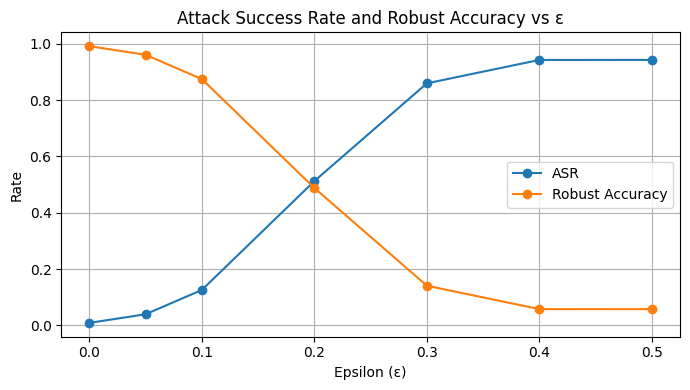

In [27]:
epsilons = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

asr_values = [attack_success_rate(model, testloader, eps) for eps in epsilons]
robust_acc = [1 - asr for asr in asr_values]

for eps, asr, rob in zip(epsilons, asr_values, robust_acc):
    print(f"ε={eps:.2f} | ASR: {asr:.1%} | Robust Accuracy: {rob:.1%}")

plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_values, marker='o', label='ASR')
plt.plot(epsilons, robust_acc, marker='o', label='Robust Accuracy')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Rate')
plt.title('Attack Success Rate and Robust Accuracy vs ε')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretation:

The ASR increases with ε while robust accuracy falls as a mirror image, which is expected. What is more interesting is the *shape* of the curve. The model stays relatively robust up to ε=0.1 (87.4% robust accuracy), then drops sharply through ε=0.2 and ε=0.3, before plateauing around 94% ASR at ε=0.4 and staying flat at ε=0.5. This non-linearity suggests the model has a kind of tipping point: most samples sit far enough from the decision boundary that small perturbations cannot reach it, but once ε crosses a threshold, a large fraction of samples gets pushed over simultaneously. The plateau at the top is equally telling: the remaining ~6% of the test set appears effectively unattackable at any practical budget, which is consistent with what we saw qualitatively with digits like 2, which resisted even maximum perturbation.

It is also worth noting that beyond ε=0.3 the perturbation becomes visually obvious. This makes the regime above 0.3 mostly academic: an attack that is perceptible defeats the whole point of adversarial examples. The practically relevant and concerning range is 0.05 to 0.2, where the attack transitions from barely effective to devastating while remaining invisible, and this is precisely where the curve bends the most.



## 3. Perturbation Norms
- **L∞ (L-infinity)**: Maximum per-pixel change: max|δᵢⱼ|
- **L₂ (Euclidean)**: Total energy: √(Σδᵢⱼ²)
- **L₀**: Number of changed pixels: |{(i,j) : δᵢⱼ ≠ 0}|


=== Perturbation Norms at ε=0.05 ===
Average L∞: 0.1623
Average L2: 2.7861
Average L0: 311.9 pixels changed

=== Perturbation Norms at ε=0.1 ===
Average L∞: 0.3246
Average L2: 5.5404
Average L0: 311.9 pixels changed

=== Perturbation Norms at ε=0.2 ===
Average L∞: 0.6491
Average L2: 10.9749
Average L0: 311.9 pixels changed

=== Perturbation Norms at ε=0.3 ===
Average L∞: 0.9737
Average L2: 16.3186
Average L0: 311.9 pixels changed


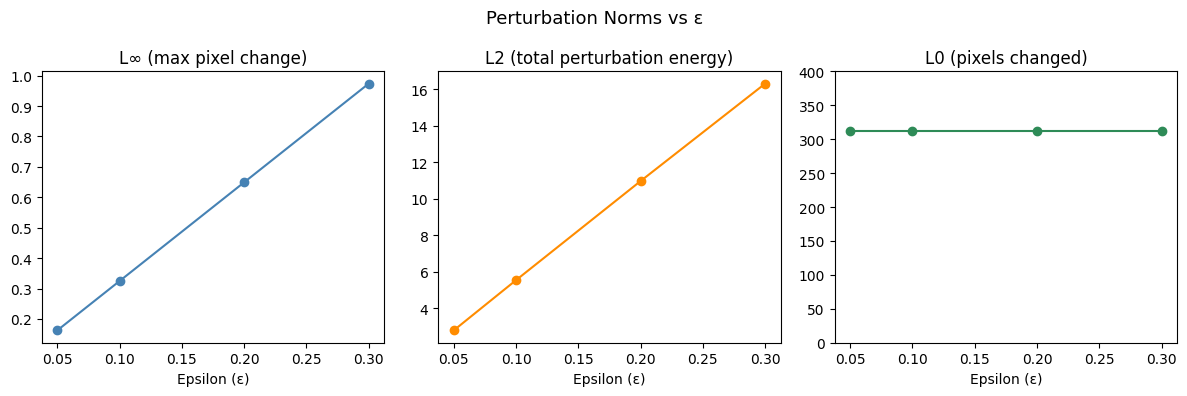

In [29]:
def perturbation_norms(model, dataloader, eps):
    l_inf_list, l2_list, l0_list = [], [], []
    
    for images, labels in dataloader:
        adv_images, _ = fgsm_attack(model, images, labels, eps)
        delta = adv_images - images.to(device)
        
        for i in range(len(delta)):
            d = delta[i]
            l_inf_list.append(d.abs().max().item())
            l2_list.append(d.pow(2).sum().sqrt().item())
            l0_list.append((d.abs() > 1e-6).sum().item())
    
    avg_linf = sum(l_inf_list) / len(l_inf_list)
    avg_l2   = sum(l2_list)    / len(l2_list)
    avg_l0   = sum(l0_list)    / len(l0_list)
    
    # still prints as before, but now also returns the values
    print(f"Average L∞: {avg_linf:.4f}")
    print(f"Average L2: {avg_l2:.4f}")
    print(f"Average L0: {avg_l0:.1f} pixels changed")
    
    return avg_linf, avg_l2, avg_l0


# collect results across epsilons
epsilons = [0.05, 0.1, 0.2, 0.3]
l_inf_vals, l2_vals, l0_vals = [], [], []

for eps in epsilons:
    print(f"\n=== Perturbation Norms at ε={eps} ===")
    l_inf, l2, l0 = perturbation_norms(model, testloader, eps)
    l_inf_vals.append(l_inf)
    l2_vals.append(l2)
    l0_vals.append(l0)


# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(epsilons, l_inf_vals, marker='o', color='steelblue')
axes[0].set_title('L∞ (max pixel change)')
axes[0].set_xlabel('Epsilon (ε)')

axes[1].plot(epsilons, l2_vals, marker='o', color='darkorange')
axes[1].set_title('L2 (total perturbation energy)')
axes[1].set_xlabel('Epsilon (ε)')

axes[2].plot(epsilons, l0_vals, marker='o', color='seagreen')
axes[2].set_title('L0 (pixels changed)')
axes[2].set_xlabel('Epsilon (ε)')
axes[2].set_ylim(0, 400)

plt.suptitle('Perturbation Norms vs ε', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

The three plots together confirm that FGSM distributes its perturbation budget in a very specific way. L∞ and L2 both grow linearly with ε, which is unsurprising: FGSM scales a fixed sign pattern by ε uniformly, so both the maximum per-pixel change and the total perturbation energy increase proportionally.

The most revealing result is the L0 plot, which stays completely flat at 311.9 pixels across all epsilon values. This is a direct consequence of how FGSM works: the gradient sign is computed once from the image structure, and it determines which pixels get perturbed. Increasing ε does not recruit new pixels into the attack, it only pushes the same ones harder. The ~312 pixels correspond to the non-background region of the average MNIST image, out of 784 total in a 28×28 grid, which also serves as a sanity check that the implementation is correct.

A useful way to think about the three norms together is that L0 describes the *shape* of the attack, which is fixed, while L∞ and L2 describe its *intensity*, which grows. FGSM gets stronger not by spreading wider, but by concentrating more energy into the same structural regions of the image.

This also connects back to the robustness question. Every image sits somewhere in a 784-dimensional space, and the model has carved that space into 10 regions separated by decision boundaries. FGSM always pushes an image in the same relative direction (determined by the gradient sign) and only varies how hard it pushes. The images that survive even at ε=0.3 are the ones that sit genuinely far from any decision boundary, not lucky — the flat L0 line rules out the possibility that the attack is failing because it missed the right pixels. It always hits the same pixels. The ones that resist simply need a harder push than any practical ε can provide, which connects back to what we saw qualitatively with the digit 2.

## 4: Confidence Changes — how much does the model's confidence in the correct class drop: 


=== Confidence Changes at ε=0.0 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 99.0%
Average confidence drop: 0.0%

=== Confidence Changes at ε=0.05 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 95.1%
Average confidence drop: 3.9%

=== Confidence Changes at ε=0.1 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 82.5%
Average confidence drop: 16.4%

=== Confidence Changes at ε=0.2 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 33.5%
Average confidence drop: 65.5%

=== Confidence Changes at ε=0.3 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 13.8%
Average confidence drop: 85.2%

=== Confidence Changes at ε=0.4 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 8.9%
Average confidence drop: 90.0%

=== Confidence Changes at ε=0.5 ===
Average confidence on true class — Clean: 99.0% | Adversarial: 7.4%
Average confidence drop: 91.5%


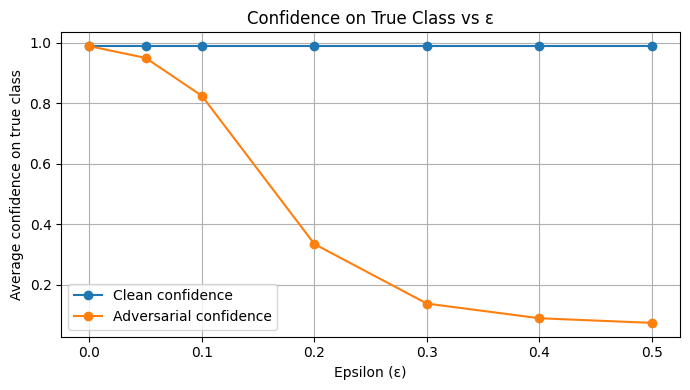

In [31]:
def confidence_changes(model, dataloader, eps):
    clean_confs, adv_confs = [], []
    
    for images, labels in dataloader:
        _, probs_clean = predict_probs(model, images)
        adv_images, _ = fgsm_attack(model, images, labels, eps)
        _, probs_adv = predict_probs(model, adv_images)
        
        for i in range(len(labels)):
            true_label = labels[i].item()
            clean_confs.append(probs_clean[i][true_label])
            adv_confs.append(probs_adv[i][true_label])
    
    avg_clean = sum(clean_confs) / len(clean_confs)
    avg_adv   = sum(adv_confs)   / len(adv_confs)
    
    print(f"Average confidence on true class — Clean: {avg_clean:.1%} | Adversarial: {avg_adv:.1%}")
    print(f"Average confidence drop: {avg_clean - avg_adv:.1%}")
    
    return avg_clean, avg_adv


epsilons = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
clean_vals, adv_vals = [], []

for eps in epsilons:
    print(f"\n=== Confidence Changes at ε={eps} ===")
    avg_clean, avg_adv = confidence_changes(model, testloader, eps)
    clean_vals.append(avg_clean)
    adv_vals.append(avg_adv)

plt.figure(figsize=(7, 4))
plt.plot(epsilons, clean_vals, marker='o', label='Clean confidence')
plt.plot(epsilons, adv_vals,   marker='o', label='Adversarial confidence')
plt.xlabel('Epsilon (ε)')
plt.ylabel('Average confidence on true class')
plt.title('Confidence on True Class vs ε')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### interpretation

The clean confidence stays flat at 99% across all epsilon values, which makes sense since epsilon does not affect the original images. What is interesting is the orange line. At ε=0.05 the adversarial confidence on the true class only drops to 95.1%, meaning the model is still mostly convinced it is looking at the right digit even after the attack. By ε=0.2 that drops to 33.5%, and by ε=0.3 it is down to 13.8%, which means the model has essentially lost all conviction in its original prediction.

This connects well to what we saw in the qualitative section. When the attack succeeded on the digit 9 at ε=0.2, the model predicted 4 with 56.6% confidence — the adversarial confidence on the *true* class (9) would have been very low at that point, consistent with what we see here on average. The model is not just wrong, it is genuinely confused and spread thin across multiple classes, which is exactly what a 13.8% average confidence on the true class implies.

The confidence drop also plateaus after ε=0.3, mirroring the ASR plateau we observed earlier, which makes sense: once most samples have been pushed well past the decision boundary, squeezing more perturbation in does not meaningfully reduce the residual confidence further.

## ***TARGETED FGSM ATTACK***

## Variants of FGSM: Targeted Attack

So far we've used **untargeted FGSM**: making the model predict ANY wrong class.

Now let's implement **targeted FGSM**: forcing the model to predict a SPECIFIC
target class.

### Mathematical Difference:

**Untargeted**:
```
δ = ε · sign(∇ₓ L(f(x), y_true))  # Maximize loss for true class
```

**Targeted**:
```
δ = -ε · sign(∇ₓ L(f(x), y_target))  # Minimize loss for target class
```

The negative sign makes us move TOWARD the target class instead of AWAY from
the true class.

### Why Targeted Attacks?

- More challenging (must satisfy specific constraint)
- Relevant for specific attack scenarios (e.g., impersonation)
- Tests fine-grained model behavior
- Often requires larger ε or multiple iterations

In [ ]:
def fgsm_targeted(model, images, target_labels, eps):
    """
    Targeted Fast Gradient Sign Method

    Args:
        model: Target neural network
        images: Clean input images (normalized)
        target_labels: Desired output labels
        eps: Perturbation budget

    Returns:
        adv_images: Adversarial examples
        sign_grad: Sign of gradient
    """

    model.eval()
    images = images.clone().detach().to(device)
    target_labels = target_labels.to(device)

    images.requires_grad = True

    output = model(images)
    loss = nn.NLLLoss()(output, target_labels)

    model.zero_grad()
    loss.backward()
    eps_norm = eps / MNIST_STD
    sign_grad = images.grad.data.sign()

    adv_images = images - eps_norm * sign_grad

    min_norm = (0.0 - MNIST_MEAN) / MNIST_STD
    max_norm = (1.0 - MNIST_MEAN) / MNIST_STD

    adv_images = torch.clamp(adv_images, min_norm, max_norm)

    return adv_images.detach(), sign_grad.detach()

def test_targeted_attack(model, dataset, source_class, target_class, eps, num_samples=10):
    """
    Test targeted attack: make source_class predict as target_class

    Args:
        model: Neural network
        dataset: Test dataset
        source_class: Original class to attack
        target_class: Desired prediction
        eps: Perturbation budget
        num_samples: Number of samples to test
    """
    model.eval()

    # Find samples of source class
    source_indices = []
    for i in range(len(dataset)):
        if dataset[i][1] == source_class:
            source_indices.append(i)
        if len(source_indices) >= num_samples:
            break

    if len(source_indices) == 0:
        print(f"No samples found for class {source_class}")
        return

    successes = 0

    print(f"\nTargeted Attack: {source_class} → {target_class} with ε={eps}")
    print(f"{'='*60}")

    for idx in source_indices:
        img_norm, label = dataset[idx][0].unsqueeze(0), torch.tensor([dataset[idx][1]])
        target = torch.tensor([target_class])

        # Clean prediction
        pred_clean, prob_clean = predict_probs(model, img_norm)

        # Generate targeted adversarial example
        adv_norm, _ = fgsm_targeted(model, img_norm, target, eps)
        pred_adv, prob_adv = predict_probs(model, adv_norm)

        success = (pred_adv[0] == target_class)
        if success:
            successes += 1

        status = "✓" if success else "✗"
        print(f"{status} Sample {idx}: Clean={pred_clean[0]} ({prob_clean[0][pred_clean[0]]:.2f}) "
              f"→ Adv={pred_adv[0]} ({prob_adv[0][pred_adv[0]]:.2f})")

    success_rate = successes / len(source_indices)
    print(f"{'='*60}")
    print(f"Success Rate: {successes}/{len(source_indices)} ({success_rate:.1%})")
    print(f"{'='*60}\n")

# Test targeted attacks
print("Testing Targeted FGSM Attacks:\n")
test_targeted_attack(model, testset, source_class=7, target_class=8, eps=0.35, num_samples=10)
test_targeted_attack(model, testset, source_class=3, target_class=5, eps=0.15, num_samples=10)
test_targeted_attack(model, testset, source_class=5, target_class=3, eps=0.25, num_samples=10)


Testing Targeted FGSM Attacks:


Targeted Attack: 7 → 8 with ε=0.35
✓ Sample 0: Clean=7 (1.00) → Adv=8 (0.29)
✗ Sample 17: Clean=7 (1.00) → Adv=9 (0.13)
✗ Sample 26: Clean=7 (1.00) → Adv=4 (0.18)
✓ Sample 34: Clean=7 (1.00) → Adv=8 (0.48)
✓ Sample 36: Clean=7 (1.00) → Adv=8 (0.42)
✓ Sample 41: Clean=7 (1.00) → Adv=8 (0.15)
✓ Sample 60: Clean=7 (1.00) → Adv=8 (0.18)
✓ Sample 64: Clean=7 (1.00) → Adv=8 (0.40)
✓ Sample 70: Clean=7 (1.00) → Adv=8 (0.19)
✓ Sample 75: Clean=7 (1.00) → Adv=8 (0.32)
Success Rate: 8/10 (80.0%)


Targeted Attack: 3 → 5 with ε=0.15
✓ Sample 18: Clean=3 (1.00) → Adv=5 (0.88)
✗ Sample 30: Clean=3 (1.00) → Adv=3 (0.96)
✗ Sample 32: Clean=3 (1.00) → Adv=3 (0.97)
✓ Sample 44: Clean=3 (1.00) → Adv=5 (0.53)
✗ Sample 51: Clean=3 (1.00) → Adv=3 (0.99)
✗ Sample 63: Clean=3 (1.00) → Adv=8 (0.53)
✗ Sample 68: Clean=3 (1.00) → Adv=3 (0.94)
✗ Sample 76: Clean=3 (1.00) → Adv=3 (0.92)
✗ Sample 87: Clean=3 (1.00) → Adv=3 (0.77)
✗ Sample 90: Clean=3 (1.00) → Adv=3 (0.97)
Success R

### Observations:

- Targeted attacks typically require **larger epsilon** than untargeted
- Success rate depends on **semantic distance** between classes
- Similar-looking digits (3→8, 5→6) are easier than dissimilar ones (7→1)
- Some targets may be impossible at reasonable epsilon values
